In [1]:
import librosa
import pathlib
import numpy as np
import pandas as pd
from tqdm import tqdm
import tensorflow as tf
from numpy import pi as PI
from keras.layers import Dense
import matplotlib.pyplot as plt
from os import listdir, makedirs
from sklearn.utils import shuffle
from keras.models import Sequential
from os.path import join, exists, getsize
from tensorflow.keras.regularizers import l2
# from cmsisdsp import arm_cos_f32, arm_float_to_q15
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.initializers import RandomUniform
from keras.layers import Conv2D, MaxPooling2D, Flatten
# from cmsisdsp import arm_mult_q15, arm_rfft_instance_q15, arm_rfft_init_q15, arm_rfft_q15, arm_cmplx_mag_q15

2024-03-06 11:41:00.743277: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-03-06 11:41:00.744446: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2024-03-06 11:41:00.761224: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-03-06 11:41:00.761242: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-03-06 11:41:00.761754: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

In [2]:
SAMPLING_FREQUENCY = 8000
MAX_LEN = 8000
WINDOW_SIZE = 256
STEP_SIZE = 128
NUM_WINDOWS = int(1 + (SAMPLING_FREQUENCY - WINDOW_SIZE) // STEP_SIZE)
NUM_FFT_BINS = int(WINDOW_SIZE // 2 + 1)

UNITS = 25
LEARNING_RATE = 0.01 
NUM_CLASSES = 2
EPOCHS = 20 
BATCH_SIZE = 32
# IN_SHAPE = (8000,)
IN_SHAPE = (61, 129)
VALIDATION_SIZE = 0.25

In [3]:
def create_folder(directory):
    if not exists(directory):
        makedirs(directory)

In [4]:
create_folder("./saved_models")
create_folder("./header_files")

In [5]:
DATA_PATH = "/home/icfoss/Datasets/kws_data/archive/"
CHECKPOINT_MODEL_PATH = join("./saved_models","dnn_model.keras")
SAVED_MODEL_PATH = "./saved_models"
TFLITE_MODEL_PATH = join("./saved_models","dnn_model.tflite")
TFLITE_OPT_MODEL_PATH = join("./saved_models","dnn_model_opt.tflite")

In [6]:
SELECTED_KEYWORDS = ["yes", "no"]
all_paths = []

yes_audios = listdir(join(DATA_PATH, "yes"))
no_audios = listdir(join(DATA_PATH, "no"))

for yes_audio in yes_audios:
    yes_path = join(join(DATA_PATH, "yes"), yes_audio)
    all_paths.append([yes_path, "yes"])

for no_audio in no_audios:
    no_path = join(join(DATA_PATH, "no"), no_audio)
    all_paths.append([no_path, "no"])
    
basic_data = pd.DataFrame(all_paths, columns=["Path", "Label"])

In [7]:
basic_data = shuffle(basic_data, random_state=33)
basic_data.loc[basic_data["Label"] == "yes", "Label"] = 1
basic_data.loc[basic_data["Label"] == "no", "Label"] = 0

In [8]:
stat = basic_data["Label"].value_counts()
print(stat*100/stat.sum())

Label
1    50.644959
0    49.355041
Name: count, dtype: float64


In [9]:
X = basic_data["Path"]
y = basic_data["Label"].astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=45, stratify=y)

In [10]:
def read_and_pad_seq(X, max_length=8000):
    X_seq = np.empty((0, max_length), float)
    for index, file_path in tqdm(X.items(), total = X.shape[0]): 
        audio_segment, _ = librosa.load(file_path, sr=8000)
        k = audio_segment.shape[0]
        if k>=max_length:
            audio_segment = audio_segment[:max_length]
        elif k<max_length:
            audio_segment = np.pad(audio_segment,(0,max_length-k),'constant')
        X_seq = np.vstack((X_seq, audio_segment))
    return X_seq

In [11]:
X_train_seq = read_and_pad_seq(X_train)
X_test_seq = read_and_pad_seq(X_test)

100%|██████████████████████████| 2396/2396 [00:21<00:00, 114.09it/s]


In [34]:
def create_hanning_window(WINDOW_SIZE):
    hanning_window_f32 = np.zeros(WINDOW_SIZE)
    for i in range(WINDOW_SIZE):
        hanning_window_f32[i] = 0.5 * (1 - arm_cos_f32(2 * PI * i / WINDOW_SIZE ))
    hanning_window_q15 = arm_float_to_q15(hanning_window_f32)
    return hanning_window_q15

In [35]:
hanning_window = np.hanning(WINDOW_SIZE)

def compute_spectrogram_new(raw_data, NUM_WINDOWS, NUM_FFT_BINS, STEP_SIZE, WINDOW_SIZE, hanning_window):
    spectrogram = np.empty((NUM_WINDOWS, NUM_FFT_BINS))
    for index in range(NUM_WINDOWS):
        window_start = index*STEP_SIZE
        window_end = window_start+WINDOW_SIZE
        window = raw_data[window_start:window_end]
        processed_window = window * hanning_window
        raw_fft = np.fft.rfft(processed_window)
        spectrogram[index] = np.abs(raw_fft)
    return spectrogram

In [14]:
# hanning_window_q15 = create_hanning_window(WINDOW_SIZE)
# rfft_instance_q15 = arm_rfft_instance_q15()

# def compute_spectrogram_arm(raw_data, NUM_WINDOWS, NUM_FFT_BINS, STEP_SIZE, WINDOW_SIZE, hanning_window_q15, rfft_instance_q15):
#     audio_samples_q15 = arm_float_to_q15(raw_data)
#     spectrogram_q15 = np.empty((NUM_WINDOWS, NUM_FFT_BINS))
#     start_index = 0
#     for index in range(NUM_WINDOWS):
#       audio_window_q15 = audio_samples_q15[start_index:start_index + WINDOW_SIZE]
#       processed_audio_q15 = arm_mult_q15(audio_window_q15, hanning_window_q15)
#       rfft_q15 = arm_rfft_q15(rfft_instance_q15, processed_audio_q15)
#       rfft_mag_q15 = arm_cmplx_mag_q15(rfft_q15)[:NUM_FFT_BINS]
#       spectrogram_q15[index] = rfft_mag_q15
#       start_index += STEP_SIZE
#     return spectrogram_q15

In [15]:
def convert_to_spectrogram(X_seq, hanning_window_q15):
    X_spectrogram = []
    for row in tqdm(X_seq):
        spectrum = compute_spectrogram_new(row, NUM_WINDOWS, NUM_FFT_BINS, STEP_SIZE, WINDOW_SIZE, hanning_window) 
        X_spectrogram.append(spectrum)
    X_spectrogram = np.asarray(X_spectrogram)
    return X_spectrogram

X_train_spectrogram = convert_to_spectrogram(X_train_seq, hanning_window)
X_test_spectrogram = convert_to_spectrogram(X_test_seq, hanning_window)

100%|█████████████████████████| 2396/2396 [00:00<00:00, 6733.70it/s]


In [61]:
class LossHistory(tf.keras.callbacks.Callback):
    def __init__(self,validation_data): 
        self.x_test = validation_data[0] 
        self.y_test= validation_data[1]
        
def on_train_begin(self, logs={}):
    self.history={'loss': [],'accuracy': [],'val_loss': [],'val_accuracy': [],'val_f1': []}
    
def on_epoch_end(self, epoch, logs={}):
    self.history['loss'].append(logs.get('loss')) 
    self.history['accuracy'].append(logs.get('accuracy'))
    
    if logs.get('val_loss', -1) != -1: 
        self.history['val_loss'].append(logs.get('val_loss'))
    if logs.get('val_accuracy', -1) != -1: 
        self.history['val_accuracy'].append(logs.get('val_accuracy'))
        
    y_pred= self.model.predict(self.x_test)
    y_label_pred = np.argmax(y_pred,axis=1) 
    y_test_arg = self.y_test
    F1 = f1_score(y_test_arg, y_label_pred, average='micro')
    self.history['val_f1'].append(F1)
    print(' Val F1 Score : ', np.round(F1,4))

In [62]:
adam_opt = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE,
                                   beta_1=0.9,
                                   beta_2=0.999,
                                   epsilon=1e-8)

In [63]:
def myDNN(in_shape, adam_opt):
    model = Sequential()
    model.add(Dense(8, kernel_initializer=RandomUniform(minval=-0.05,
                    maxval=0.05), kernel_regularizer=l2(0.001),
                    activation='relu'))
    model.add(Flatten())
    model.add(Dense(16, kernel_initializer=RandomUniform(minval=-0.05,
                    maxval=0.05), kernel_regularizer=l2(0.001),
                    activation='relu'))
    model.add(Dense(2, kernel_initializer=RandomUniform(minval=-0.05,
                    maxval=0.05), kernel_regularizer=l2(0.001),
                    activation='softmax'))
    model.compile(optimizer= adam_opt,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [64]:
cp_callback = ModelCheckpoint(filepath=SAVED_MODEL_PATH,
                              monitor="val_accuracy",
                              verbose=1,
                              save_best_only=True,
                              mode="max")

In [65]:
dnn_model = myDNN(IN_SHAPE, adam_opt)

In [66]:
dnn_model.summary()

ValueError: This model has not yet been built. Build the model first by calling `build()` or by calling the model on a batch of data.

In [ ]:
history = dnn_model.fit(X_train_spectrogram,
                        y_train,
                        batch_size=BATCH_SIZE,
                        epochs=EPOCHS,
                        validation_data=(X_test_spectrogram, y_test),
                        callbacks=[cp_callback])

Epoch 1/20
146/175 [========================>.....] - ETA: 0s - loss: 0.3741 - accuracy: 0.8761
Epoch 1: val_accuracy improved from -inf to 0.90150, saving model to ./saved_models
INFO:tensorflow:Assets written to: ./saved_models/assets


INFO:tensorflow:Assets written to: ./saved_models/assets


175/175 [==============================] - 1s 3ms/step - loss: 0.3602 - accuracy: 0.8805 - val_loss: 0.3130 - val_accuracy: 0.9015
Epoch 2/20
169/175 [===========================>..] - ETA: 0s - loss: 0.2624 - accuracy: 0.9314
Epoch 2: val_accuracy improved from 0.90150 to 0.91653, saving model to ./saved_models
INFO:tensorflow:Assets written to: ./saved_models/assets


INFO:tensorflow:Assets written to: ./saved_models/assets


175/175 [==============================] - 0s 2ms/step - loss: 0.2626 - accuracy: 0.9318 - val_loss: 0.2684 - val_accuracy: 0.9165
Epoch 3/20
167/175 [===========================>..] - ETA: 0s - loss: 0.2428 - accuracy: 0.9360
Epoch 3: val_accuracy improved from 0.91653 to 0.94157, saving model to ./saved_models
INFO:tensorflow:Assets written to: ./saved_models/assets


...

INFO:tensorflow:Assets written to: ./saved_models/assets


175/175 [==============================] - 0s 3ms/step - loss: 0.2275 - accuracy: 0.9524 - val_loss: 0.2491 - val_accuracy: 0.9441
Epoch 12/20
154/175 [=========================>....] - ETA: 0s - loss: 0.2203 - accuracy: 0.9558
Epoch 12: val_accuracy did not improve from 0.94407
175/175 [==============================] - 0s 936us/step - loss: 0.2207 - accuracy: 0.9554 - val_loss: 0.3003 - val_accuracy: 0.9278
Epoch 13/20
172/175 [============================>.] - ETA: 0s - loss: 0.2177 - accuracy: 0.9535
Epoch 13: val_accuracy did not improve from 0.94407
175/175 [==============================] - 0s 1ms/step - loss: 0.2194 - accuracy: 0.9531 - val_loss: 0.2586 - val_accuracy: 0.9336
Epoch 14/20
153/175 [=========================>....] - ETA: 0s - loss: 0.2081 - accuracy: 0.9561
Epoch 14: val_accuracy improved from 0.94407 to 0.94491, saving model to ./saved_models
INFO:tensorflow:Assets written to: ./saved_models/assets


INFO:tensorflow:Assets written to: ./saved_models/assets


175/175 [==============================] - 0s 2ms/step - loss: 0.2037 - accuracy: 0.9583 - val_loss: 0.2395 - val_accuracy: 0.9449
Epoch 15/20
134/175 [=====================>........] - ETA: 0s - loss: 0.2098 - accuracy: 0.9534
Epoch 15: val_accuracy improved from 0.94491 to 0.94950, saving model to ./saved_models
INFO:tensorflow:Assets written to: ./saved_models/assets


INFO:tensorflow:Assets written to: ./saved_models/assets


In [42]:
def qualityLinePlot(history, labelsize=12, width=5):
    plt.rc("font", family="serif")
    plt.rc("xtick", labelsize=labelsize)
    plt.rc("ytick", labelsize=labelsize)
    plt.rc("axes", labelsize=labelsize)

    height = width / 1.618
    fig1, ax1 = plt.subplots()
    fig1.subplots_adjust(left=0.16, bottom=0.2, right=0.99, top=0.90)
    plt.plot(history.history["accuracy"])
    plt.plot(history.history["val_accuracy"])
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend(["Training", "Validation"], loc="upper right")
    plt.show()

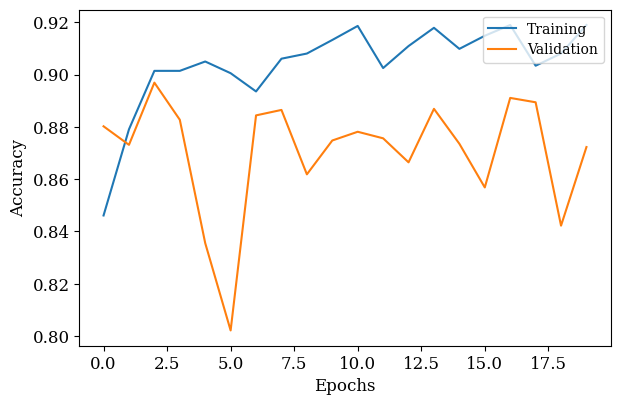

In [43]:
qualityLinePlot(history)

In [44]:
tf.saved_model.save(dnn_model, SAVED_MODEL_PATH)
converter = tf.lite.TFLiteConverter.from_saved_model(SAVED_MODEL_PATH)
tflite_model = converter.convert()

tflite_model_file = pathlib.Path(TFLITE_MODEL_PATH)
model_size_kb = tflite_model_file.write_bytes(tflite_model) /  1024
print("Size of TensorFlow Lite Model: {} KB:".format(model_size_kb))

converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model_opt = converter.convert()

tflite_model_opt_1 = pathlib.Path(TFLITE_OPT_MODEL_PATH)
model_size_kb_opt = tflite_model_opt_1 .write_bytes(tflite_model_opt) /  1024
print("Size of TensorFlow Lite Opt Model: {} KB:".format(model_size_kb_opt))

size_reduction = np.round(model_size_kb / model_size_kb_opt, 1)
print("There is {}x reduction in size".format(size_reduction))

INFO:tensorflow:Assets written to: ./saved_models/assets


INFO:tensorflow:Assets written to: ./saved_models/assets


Size of TensorFlow Lite Model: 3749.5078125 KB:


2024-03-06 11:49:09.286033: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2024-03-06 11:49:09.286050: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2024-03-06 11:49:09.286135: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: ./saved_models
2024-03-06 11:49:09.286636: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2024-03-06 11:49:09.286644: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: ./saved_models
2024-03-06 11:49:09.287807: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2024-03-06 11:49:09.308591: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: ./saved_models
2024-03-06 11:49:09.313597: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 27462 microse

Size of TensorFlow Lite Opt Model: 939.703125 KB:
There is 4.0x reduction in size


onverted Ops: 6, Total Ops 15, % non-converted = 40.00 %
 * 6 ARITH ops

- arith.constant:    6 occurrences  (f32: 5, i32: 1)



  (f32: 1)
  (f32: 2)
  (uq_8: 1)
  (f32: 1)
  (f32: 1)


In [52]:
!echo "const unsigned char model[] = {" > model.h
!cat saved_models/dnn_model_opt.tflite | xxd -i >> header_files/model.h
!echo "};" >> header_files/model.h

model_h_size = getsize("./saved_models/dnn_model_opt.tflite")
print(f"Header file, model.h, is {model_h_size:,} bytes.")

Header file, model.h, is 962,256 bytes.
